In [1]:
import mido
import csv
import pandas as pd
import matplotlib.pyplot as plt

Convertir Archivo MIDI a CSV

In [2]:
path = "./" #Ruta del archivo
filename = "tetris" #nombre del archivo (sin extension)

In [3]:
mid = mido.MidiFile(path+filename+".mid")

filas = []
for i, track in enumerate(mid.tracks):
    tiempo_absoluto = 0
    for msg in track:
        tiempo_absoluto += msg.time  # acumular delta -> absoluto

        if msg.type in ('note_on', 'note_off'):
            filas.append({
                'track': i,
                'channel': msg.channel,
                'type': msg.type,
                'note': msg.note,
                'velocity': msg.velocity,
                'time': tiempo_absoluto
            })

# Guardar CSV
with open(path+filename+'.csv', 'w', newline='') as f:
    campos = ['track', 'channel', 'type', 'note', 'velocity', 'time']
    writer = csv.DictWriter(f, fieldnames=campos)
    writer.writeheader()
    writer.writerows(filas)

print(f"Exportadas {len(filas)} notas")
print ("ruta de archivo csv: "+path+filename+".csv")

Exportadas 374 notas
ruta de archivo csv: ./tetris.csv


In [4]:
path_csv = path+filename+".csv"

Vista previa de columnas y tipo de datos

In [5]:
df = pd.read_csv(path_csv)

print(df.head())
print(df.dtypes)  # pandas infiere los tipos automáticamente

   track  channel      type  note  velocity  time
0      1        0   note_on    76        69    10
1      1        0   note_on    52        57    10
2      1        0   note_on    64        52   546
3      1        0  note_off    52         0   576
4      1        0  note_off    76         0  1053
track       int64
channel     int64
type          str
note        int64
velocity    int64
time        int64
dtype: object


Convertir columna type de str a int

In [6]:
mapeo = {'note_on': 1, 'note_off': 0} #convertir columna type de str a int
df['type'] = df['type'].map(mapeo)

print(df.head())
print(df.dtypes)  # pandas infiere los tipos automáticamente


   track  channel  type  note  velocity  time
0      1        0     1    76        69    10
1      1        0     1    52        57    10
2      1        0     1    64        52   546
3      1        0     0    52         0   576
4      1        0     0    76         0  1053
track       int64
channel     int64
type        int64
note        int64
velocity    int64
time        int64
dtype: object


Visualizar time velocity y note en un grafico 3D

In [7]:
import plotly.express as px

# 1. Gráfico base de puntos
fig = px.scatter_3d(
    df,
    x='time',
    y='note',
    z='velocity',
    color='velocity',
    size='velocity',
    hover_name='time',
    title='time vs note vs velocity',
    color_continuous_scale='dense',
    range_color=[40, df['velocity'].max()],
    width=1000,
    height=600
)

# 2. Añadir la línea conectada (sin repetir color/size)
fig.add_trace(
    px.line_3d(
        df,
        x='time',
        y='note',
        z='velocity',
        color_discrete_sequence=['rgba(0,0,0,0.4)']  # línea negra semitransparente o gris
    ).data[0]
)

# Opcional: ajustar estilo de la línea
fig.update_traces(
    selector=dict(type='scatter3d', mode='lines'),  # solo la línea añadida
    line=dict(width=3, dash='solid')
)

fig.update_layout(
    scene=dict(
        xaxis_title='time',
        yaxis_title='note',
        zaxis_title='velocity'
    )
)

fig.show()

=== MATRIZ DE CORRELACIÓN (Pearson) ===
            note  velocity    time
note      1.0000    0.0815 -0.2105
velocity  0.0815    1.0000 -0.0329
time     -0.2105   -0.0329  1.0000


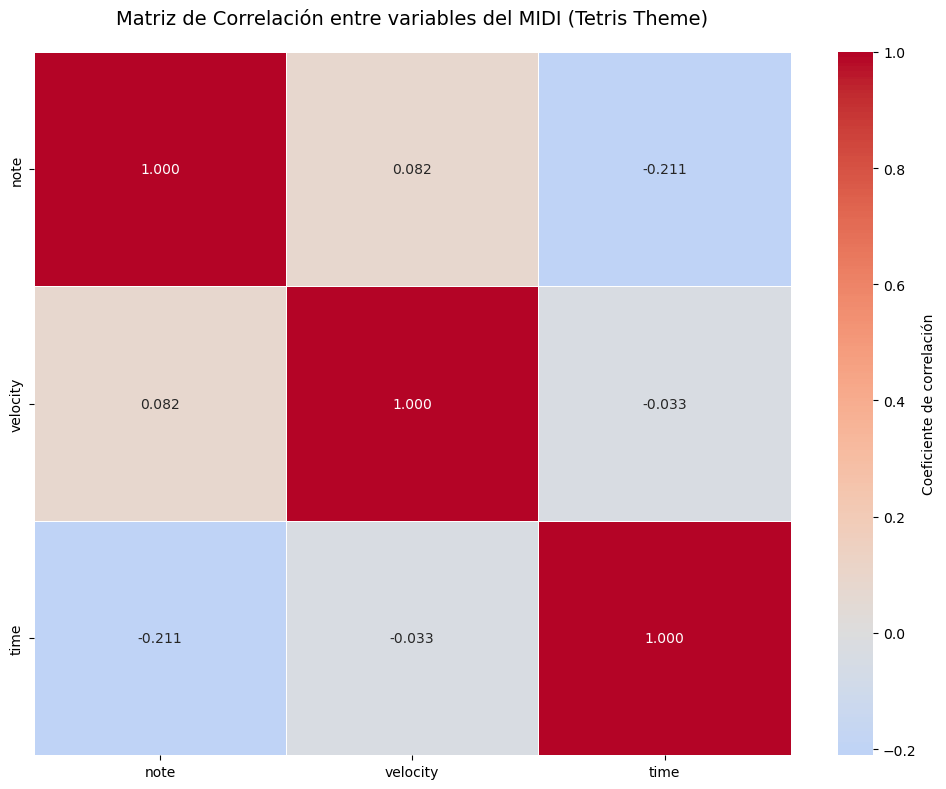


=== Correlaciones más fuertes con 'note' (target) ===
note        1.0000
velocity    0.0815
time       -0.2105
Name: note, dtype: float64

=== Observaciones para tu modelo de predicción de notas ===
- La variable 'time' tiene una correlación moderada con 'note' → el tiempo acumulado contiene información secuencial importante.
- 'velocity' suele tener correlación baja con 'note' en muchos MIDIs, pero puede ser útil como feature contextual.
- 'type' (note_on / note_off) está fuertemente relacionado con el comportamiento de las notas.
- Para predecir el 20% final, considera usar secuencias temporales (LSTM, Transformer) o features como:
   • time anterior, note anterior, velocity anterior
   • delta_time entre eventos
   • posición en el compás (si calculas ticks por beat)
   • track y channel como variables categóricas


In [ ]:
# === ANÁLISIS DE CORRELACIÓN ===
print("=== MATRIZ DE CORRELACIÓN (Pearson) ===")

# Seleccionamos solo las columnas numéricas relevantes
cols_numericas = ['track', 'channel', 'type', 'note', 'velocity', 'time'] # eliminar track, channel, type
corr_matrix = df[cols_numericas].corr(method='pearson')

print(corr_matrix.round(4))

# Visualización de la matriz de correlación (más clara y bonita)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            cmap='coolwarm', 
            center=0, 
            fmt='.3f',
            linewidths=0.5,
            cbar_kws={'label': 'Coeficiente de correlación'})
plt.title('Matriz de Correlación entre variables del MIDI (Tetris Theme)', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

# Correlaciones más fuertes con la nota (nuestro target principal)
print("\n=== Correlaciones más fuertes con 'note' (target) ===")
corr_note = corr_matrix['note'].sort_values(ascending=False)
print(corr_note.round(4))

# Comentarios útiles para tu proyecto
print("\n=== Observaciones para tu modelo de predicción de notas ===")
print("- La variable 'time' tiene una correlación moderada con 'note' → el tiempo acumulado contiene información secuencial importante.")
print("- 'velocity' suele tener correlación baja con 'note' en muchos MIDIs, pero puede ser útil como feature contextual.")
print("- 'type' (note_on / note_off) está fuertemente relacionado con el comportamiento de las notas.")
print("- Para predecir el 20% final, considera usar secuencias temporales (LSTM, Transformer) o features como:")
print("   • time anterior, note anterior, velocity anterior")
print("   • delta_time entre eventos")
print("   • posición en el compás (si calculas ticks por beat)")
print("   • track y channel como variables categóricas")